# Bar graph (most recent year) stratifying by AI exposure, y-axis will be the 2-digit (Major Group)

Using apprenticeship column: 2024 Incoming Apprenticeships


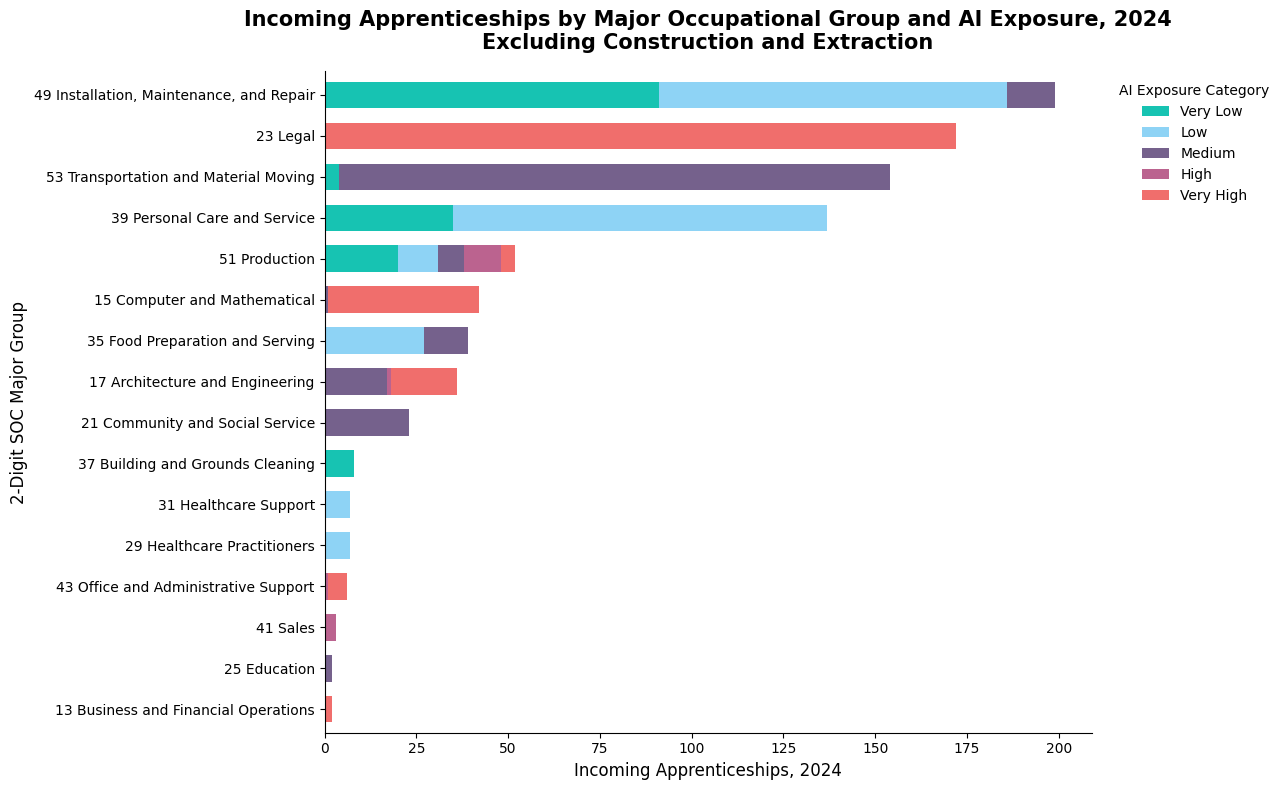

Chart saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\bar_counts_apprenticeships_ai_exposure_excluding_construction_2024.png
Data saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\bar_counts_apprenticeships_ai_exposure_excluding_construction_2024.xlsx


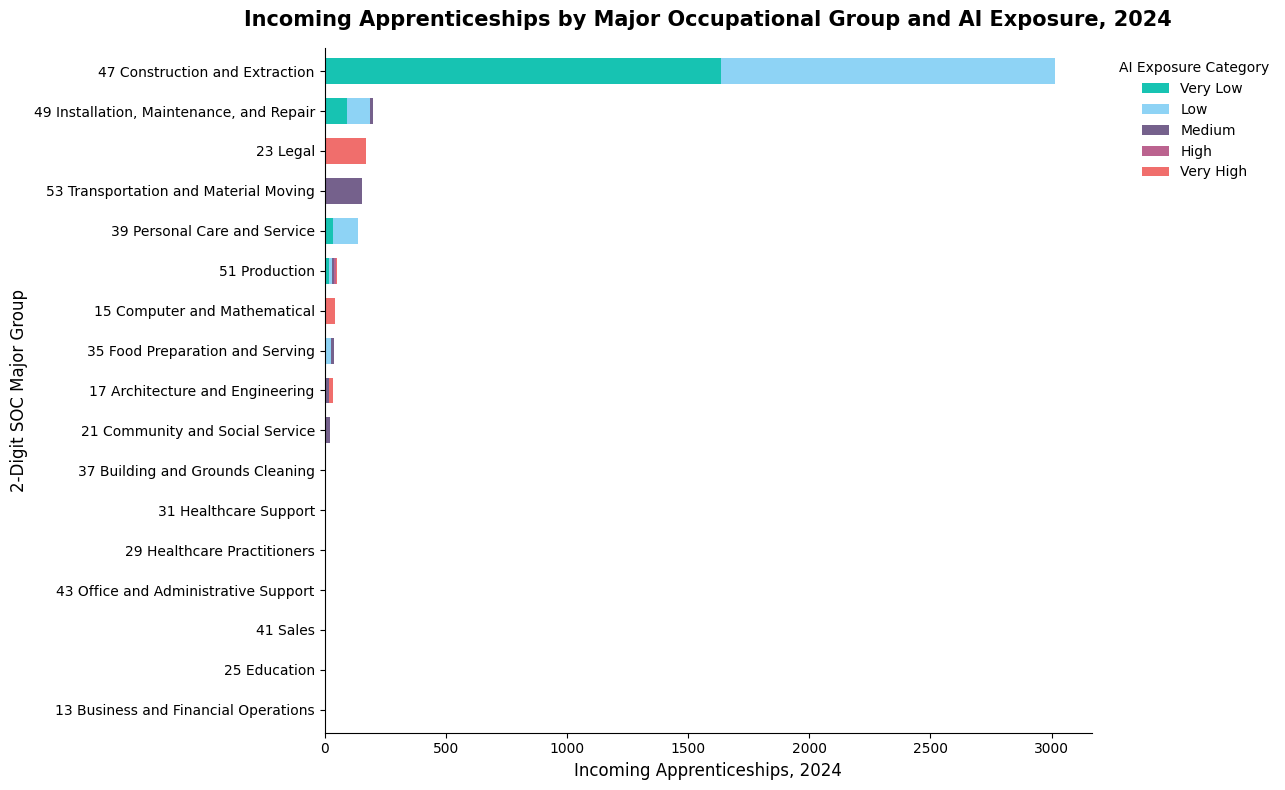

Chart saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\bar_counts_apprenticeships_ai_exposure_including_construction_2024.png
Data saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\bar_counts_apprenticeships_ai_exposure_including_construction_2024.xlsx
Done.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# FILE PATHS
# =========================================================

apprenticeship_path = Path(
    r"C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Apprenticeships_Table_2016-2025.csv"
)

ai_path = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

output_folder = Path(
    r"C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output"
)

output_folder.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

analysis_year = 2024
minimum_group_count = 1
exclude_major_groups = ["47"]

ai_colors = {
    "Very Low": "#17C3B2",
    "Low": "#8ED3F5",
    "Medium": "#75618C",
    "High": "#BB638F",
    "Very High": "#F06E6C"
}

exposure_order = ["Very Low", "Low", "Medium", "High", "Very High"]

# =========================================================
# LOAD DATA
# =========================================================

app = pd.read_csv(apprenticeship_path)
ai = pd.read_csv(ai_path)

app.columns = app.columns.str.strip()
ai.columns = ai.columns.str.strip()

# =========================================================
# CLEAN SOC CODES
# =========================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().replace(".0", "")

    month_fix = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
        "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
        "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
    }

    for month, number in month_fix.items():
        if x.startswith(month + "-"):
            x = x.replace(month + "-", number + "-", 1)

    return x

app["SOC"] = app["SOC"].apply(clean_soc)
ai["SOC"] = ai["SOC"].apply(clean_soc)

exposure_col = "AI Exposure Category"

# =========================================================
# FIND APPRENTICESHIP YEAR COLUMN
# =========================================================

year_col = None

for c in app.columns:
    if str(analysis_year) in c and "Incoming" in c:
        year_col = c
        break

if year_col is None:
    raise ValueError(f"Could not find {analysis_year} incoming apprenticeship column.")

print(f"Using apprenticeship column: {year_col}")

# =========================================================
# MERGE APPRENTICESHIP DATA WITH AI EXPOSURE
# =========================================================

merged = app.merge(
    ai[["SOC", exposure_col]],
    on="SOC",
    how="left"
)

merged["Major Group"] = merged["SOC"].str[:2]
merged[year_col] = pd.to_numeric(merged[year_col], errors="coerce").fillna(0)

merged = merged.dropna(subset=[exposure_col]).copy()

# =========================================================
# SOC MAJOR GROUP LABELS
# =========================================================

major_group_labels = {
    "11": "11 Management",
    "13": "13 Business and Financial Operations",
    "15": "15 Computer and Mathematical",
    "17": "17 Architecture and Engineering",
    "19": "19 Life, Physical, and Social Science",
    "21": "21 Community and Social Service",
    "23": "23 Legal",
    "25": "25 Education",
    "27": "27 Arts, Design, Entertainment, Sports, and Media",
    "29": "29 Healthcare Practitioners",
    "31": "31 Healthcare Support",
    "33": "33 Protective Service",
    "35": "35 Food Preparation and Serving",
    "37": "37 Building and Grounds Cleaning",
    "39": "39 Personal Care and Service",
    "41": "41 Sales",
    "43": "43 Office and Administrative Support",
    "45": "45 Farming, Fishing, and Forestry",
    "47": "47 Construction and Extraction",
    "49": "49 Installation, Maintenance, and Repair",
    "51": "51 Production",
    "53": "53 Transportation and Material Moving"
}

merged["Major Group Label"] = merged["Major Group"].map(major_group_labels)
merged = merged.dropna(subset=["Major Group Label"]).copy()

# Keep a full version before excluding Construction
merged_all = merged.copy()

# =========================================================
# FUNCTION TO MAKE CHART
# =========================================================

def make_bar_chart(data, title, output_name):
    bar_data = (
        data
        .groupby(["Major Group Label", exposure_col], as_index=False)[year_col]
        .sum()
    )

    bar_counts = (
        bar_data
        .pivot(index="Major Group Label", columns=exposure_col, values=year_col)
        .fillna(0)
    )

    existing_exposure_cols = [c for c in exposure_order if c in bar_counts.columns]
    bar_counts = bar_counts[existing_exposure_cols]

    bar_counts["Total Apprenticeships"] = bar_counts.sum(axis=1)

    # Remove groups with zero apprenticeships
    bar_counts = bar_counts[
        bar_counts["Total Apprenticeships"] > 0
    ].copy()

    # Apply minimum threshold
    bar_counts = bar_counts[
        bar_counts["Total Apprenticeships"] >= minimum_group_count
    ].copy()

    bar_counts = bar_counts.sort_values(
        "Total Apprenticeships",
        ascending=True
    )

    plot_data = bar_counts[existing_exposure_cols]

    fig, ax = plt.subplots(figsize=(13, 8))

    plot_data.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=[ai_colors[c] for c in plot_data.columns],
        width=0.65
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=16
    )

    ax.set_xlabel(f"Incoming Apprenticeships, {analysis_year}", fontsize=12)
    ax.set_ylabel("2-Digit SOC Major Group", fontsize=12)

    ax.legend(
        title="AI Exposure Category",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    png_output = output_folder / output_name
    excel_output = output_folder / output_name.replace(".png", ".xlsx")

    plt.savefig(png_output, dpi=300, bbox_inches="tight")
    bar_counts.sort_values("Total Apprenticeships", ascending=False).to_excel(excel_output)

    plt.show()

    print(f"Chart saved to: {png_output}")
    print(f"Data saved to: {excel_output}")

# =========================================================
# CHART 1: EXCLUDING CONSTRUCTION
# =========================================================

merged_excluding_construction = merged_all[
    ~merged_all["Major Group"].isin(exclude_major_groups)
].copy()

make_bar_chart(
    merged_excluding_construction,
    f"Incoming Apprenticeships by Major Occupational Group and AI Exposure, {analysis_year}\nExcluding Construction and Extraction",
    f"bar_counts_apprenticeships_ai_exposure_excluding_construction_{analysis_year}.png"
)

# =========================================================
# CHART 2: INCLUDING CONSTRUCTION
# =========================================================

make_bar_chart(
    merged_all,
    f"Incoming Apprenticeships by Major Occupational Group and AI Exposure, {analysis_year}",
    f"bar_counts_apprenticeships_ai_exposure_including_construction_{analysis_year}.png"
)

# =========================================================
# SAVE MERGED DATA
# =========================================================

merged_all.to_excel(
    output_folder / f"merged_apprenticeship_ai_exposure_{analysis_year}.xlsx",
    index=False
)

print("Done.")

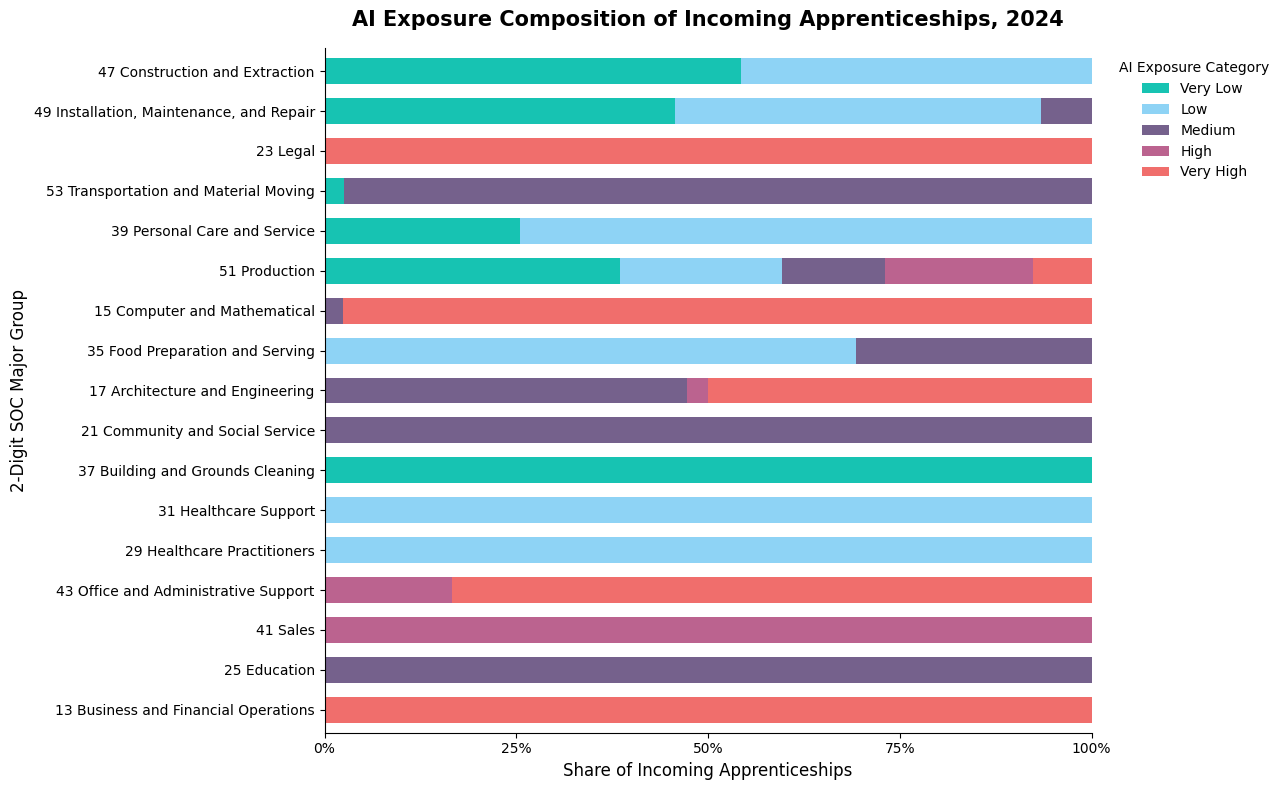

Chart saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\bar_pct_apprenticeships_ai_exposure_including_construction_2024.png
Data saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\bar_pct_apprenticeships_ai_exposure_including_construction_2024.xlsx


In [14]:
# =========================================================
# FUNCTION TO MAKE PROPORTION CHART
# =========================================================

def make_proportion_chart(data, title, output_name):

    bar_data = (
        data
        .groupby(["Major Group Label", exposure_col], as_index=False)[year_col]
        .sum()
    )

    bar_counts = (
        bar_data
        .pivot(index="Major Group Label", columns=exposure_col, values=year_col)
        .fillna(0)
    )

    existing_exposure_cols = [c for c in exposure_order if c in bar_counts.columns]
    bar_counts = bar_counts[existing_exposure_cols]

    bar_counts["Total Apprenticeships"] = bar_counts.sum(axis=1)

    # Keep only groups with apprenticeships
    bar_counts = bar_counts[
        bar_counts["Total Apprenticeships"] > 0
    ].copy()

    # Convert to percentages
    bar_pct = (
        bar_counts[existing_exposure_cols]
        .div(bar_counts["Total Apprenticeships"], axis=0)
        * 100
    )

    bar_pct["Total Apprenticeships"] = bar_counts["Total Apprenticeships"]

    # Sort by total apprenticeships
    bar_pct = bar_pct.sort_values(
        "Total Apprenticeships",
        ascending=True
    )

    plot_data = bar_pct[existing_exposure_cols]

    fig, ax = plt.subplots(figsize=(13, 8))

    plot_data.plot(
        kind="barh",
        stacked=True,
        ax=ax,
        color=[ai_colors[c] for c in plot_data.columns],
        width=0.65
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=16
    )

    ax.set_xlabel(
        "Share of Incoming Apprenticeships",
        fontsize=12
    )

    ax.set_ylabel(
        "2-Digit SOC Major Group",
        fontsize=12
    )

    ax.set_xlim(0, 100)

    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])

    ax.legend(
        title="AI Exposure Category",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    png_output = output_folder / output_name
    excel_output = output_folder / output_name.replace(".png", ".xlsx")

    plt.savefig(png_output, dpi=300, bbox_inches="tight")
    bar_pct.to_excel(excel_output)

    plt.show()

    print(f"Chart saved to: {png_output}")
    print(f"Data saved to: {excel_output}")



# =========================================================
# PROPORTION CHART 1: INCLUDING CONSTRUCTION
# =========================================================

make_proportion_chart(
    merged_all,
    f"AI Exposure Composition of Incoming Apprenticeships, {analysis_year}",
    f"bar_pct_apprenticeships_ai_exposure_including_construction_{analysis_year}.png"
)

# Line graph (2016 - present) looking at apprenticeship growth, stratified by x5 AI exposure quintiles (add add project growth line for each AI exposure category) - Research projections (contact Zimo?)

# Apprenticeship Growth Projections by AI Exposure Category

This figure analyzes incoming apprenticeship trends across occupations grouped into five AI exposure categories: Very Low, Low, Medium, High, and Very High AI exposure.

## Methodology

- Historical apprenticeship counts were aggregated annually from 2016 through 2024.
- Occupations were mapped to AI exposure categories using the AI exposure composite file.
- Apprenticeship counts were summed within each AI exposure category for each year.

## Projection Approach

To estimate future apprenticeship trends, a Compound Annual Growth Rate (CAGR) projection method was used.

- CAGR was calculated separately for each AI exposure category.
- Recent trend years (2021–2024) were used to calculate growth rates.
- Each exposure category was then projected forward annually from 2025 through 2030 using its corresponding CAGR.

## Figure Interpretation

- Solid lines represent historical apprenticeship counts (2016–2024).
- Dashed lines represent projected apprenticeship growth trends (2025–2030).
- Colors correspond to the five AI exposure categories.

## Notes

- 2025 apprenticeship data was excluded from the historical analysis because the dataset appeared incomplete/partial.
- These projections are directional trend estimates and should not be interpreted as official forecasts.

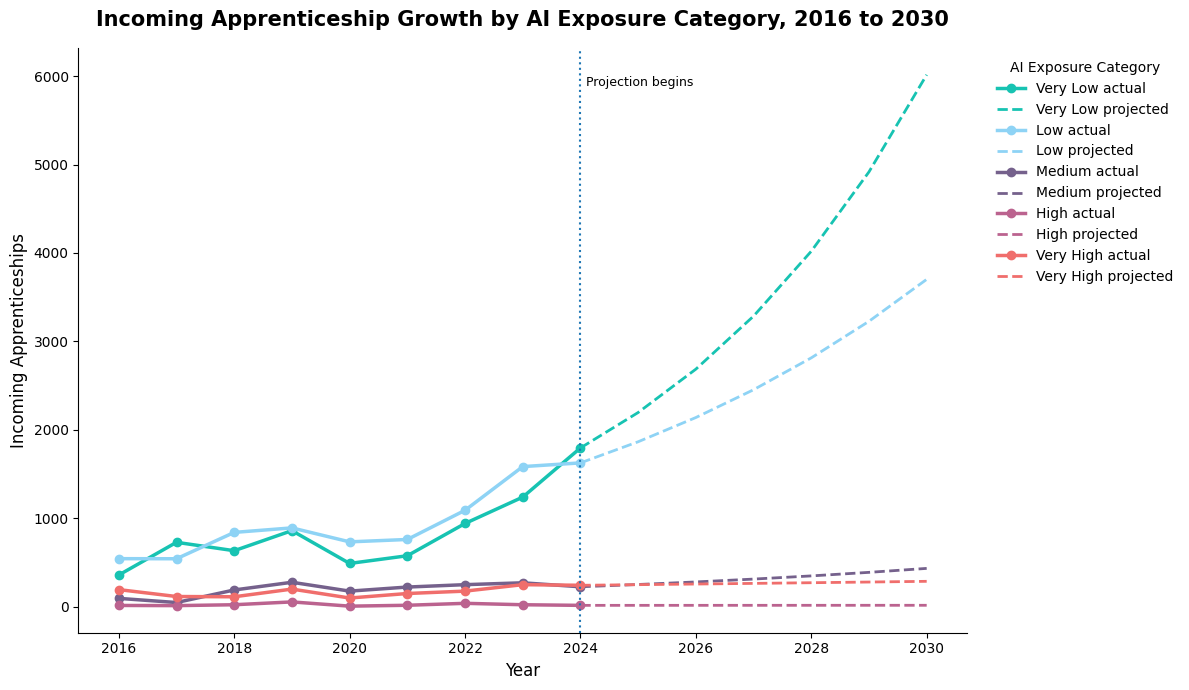

Line chart saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\line_apprenticeship_growth_by_ai_exposure_2016_2030.png
Line data saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\line_apprenticeship_growth_by_ai_exposure_2016_2030.xlsx


In [15]:
# =========================================================
# LINE GRAPH: APPRENTICESHIP GROWTH BY AI EXPOSURE
# Actuals: 2016 to 2024
# Projection: 2025 to 2030 based on 2016 to 2024 CAGR
# =========================================================

actual_start_year = 2016
actual_end_year = 2024
projection_end_year = 2030

# Find incoming apprenticeship columns
year_cols = {}

for c in app.columns:
    if "Incoming" in c:
        for year in range(actual_start_year, actual_end_year + 1):
            if str(year) in c:
                year_cols[c] = year

if not year_cols:
    raise ValueError("Could not find incoming apprenticeship columns for 2016 to 2024.")

# Use merged_all so we keep all occupations, including Construction
line_long = merged_all.melt(
    id_vars=["SOC", "Occupation", exposure_col],
    value_vars=list(year_cols.keys()),
    var_name="Year Column",
    value_name="Incoming Apprenticeships"
)

line_long["Year"] = line_long["Year Column"].map(year_cols)
line_long["Incoming Apprenticeships"] = pd.to_numeric(
    line_long["Incoming Apprenticeships"],
    errors="coerce"
).fillna(0)

# Aggregate by year and AI exposure category
line_actual = (
    line_long
    .groupby(["Year", exposure_col], as_index=False)["Incoming Apprenticeships"]
    .sum()
)

line_actual["Line Type"] = "Actual"

# =========================================================
# CREATE PROJECTIONS USING CAGR
# =========================================================

projection_rows = []

for exposure, group in line_actual.groupby(exposure_col):
    group = group.sort_values("Year")

    start_value = group.loc[
        group["Year"] == actual_start_year,
        "Incoming Apprenticeships"
    ].sum()

    end_value = group.loc[
        group["Year"] == actual_end_year,
        "Incoming Apprenticeships"
    ].sum()

    n_years = actual_end_year - actual_start_year

    if start_value > 0 and end_value > 0:
        cagr = (end_value / start_value) ** (1 / n_years) - 1
    else:
        cagr = 0

    for year in range(actual_end_year, projection_end_year + 1):
        projected_value = end_value * ((1 + cagr) ** (year - actual_end_year))

        projection_rows.append({
            "Year": year,
            exposure_col: exposure,
            "Incoming Apprenticeships": projected_value,
            "Line Type": "Projected",
            "CAGR": cagr
        })

line_projection = pd.DataFrame(projection_rows)

line_all = pd.concat(
    [line_actual, line_projection],
    ignore_index=True
)

# =========================================================
# PLOT LINE GRAPH
# =========================================================

fig, ax = plt.subplots(figsize=(12, 7))

for exposure in exposure_order:
    actual = line_all[
        (line_all[exposure_col] == exposure) &
        (line_all["Line Type"] == "Actual")
    ].sort_values("Year")

    projected = line_all[
        (line_all[exposure_col] == exposure) &
        (line_all["Line Type"] == "Projected")
    ].sort_values("Year")

    if actual.empty:
        continue

    ax.plot(
        actual["Year"],
        actual["Incoming Apprenticeships"],
        marker="o",
        linewidth=2.5,
        color=ai_colors[exposure],
        label=f"{exposure} actual"
    )

    ax.plot(
        projected["Year"],
        projected["Incoming Apprenticeships"],
        linestyle="--",
        linewidth=2,
        color=ai_colors[exposure],
        label=f"{exposure} projected"
    )

ax.set_title(
    "Incoming Apprenticeship Growth by AI Exposure Category, 2016 to 2030",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Incoming Apprenticeships", fontsize=12)

ax.axvline(
    actual_end_year,
    linestyle=":",
    linewidth=1.5
)

ax.text(
    actual_end_year + 0.1,
    ax.get_ylim()[1] * 0.95,
    "Projection begins",
    fontsize=9,
    va="top"
)

ax.legend(
    title="AI Exposure Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# =========================================================
# SAVE OUTPUTS
# =========================================================

line_png_output = output_folder / "line_apprenticeship_growth_by_ai_exposure_2016_2030.png"
line_excel_output = output_folder / "line_apprenticeship_growth_by_ai_exposure_2016_2030.xlsx"

plt.savefig(line_png_output, dpi=300, bbox_inches="tight")
line_all.to_excel(line_excel_output, index=False)

plt.show()

print(f"Line chart saved to: {line_png_output}")
print(f"Line data saved to: {line_excel_output}")

# Table 2022 - present top occupations in "very high AI exposure" w/ CAGR + LMI information (Wage, projected growth, employment)

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# FILE PATHS
# =========================================================

apprenticeship_path = Path(
    r"C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Apprenticeships_Table_2016-2025.csv"
)

ai_path = Path(
    r"G:\Shared drives\EO_ECONOMIC ANALYSIS\ea_common\Projects\AI\risk_index\ai_exposure_composite_clean.csv"
)

output_folder = Path(
    r"C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output"
)

output_folder.mkdir(parents=True, exist_ok=True)

# =========================================================
# SETTINGS
# =========================================================

exposure_col = "AI Exposure Category"
target_exposures = ["High", "Very High"]

analysis_years = [2022, 2023, 2024]

# =========================================================
# LOAD DATA
# =========================================================

app = pd.read_csv(apprenticeship_path)
ai = pd.read_csv(ai_path)

app.columns = app.columns.str.strip()
ai.columns = ai.columns.str.strip()

# =========================================================
# CLEAN SOC CODES
# =========================================================

def clean_soc(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().replace(".0", "")

    month_fix = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
        "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
        "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
    }

    for month, number in month_fix.items():
        if x.startswith(month + "-"):
            x = x.replace(month + "-", number + "-", 1)

    return x

app["SOC"] = app["SOC"].apply(clean_soc)
ai["SOC"] = ai["SOC"].apply(clean_soc)

# =========================================================
# FIND APPRENTICESHIP YEAR COLUMNS
# =========================================================

year_col_map = {}

for year in analysis_years:
    match = None

    for c in app.columns:
        if str(year) in c and "Incoming" in c:
            match = c
            break

    if match is None:
        raise ValueError(f"Could not find Incoming Apprenticeships column for {year}.")

    year_col_map[year] = match

print("Using apprenticeship columns:")
for year, col in year_col_map.items():
    print(f"{year}: {col}")

# =========================================================
# LMI COLUMNS FROM AI FILE
# =========================================================

lmi_cols = [
    "Occupation Title",
    "50th Percentile Wage",
    "SCM Employment",
    "Annual Total Openings",
    "Annual Percent Change",
    "Growth Rate",
    "Education Value",
    "Work Experience Value"
]

existing_lmi_cols = [c for c in lmi_cols if c in ai.columns]

# =========================================================
# FILTER TO HIGH + VERY HIGH AI EXPOSURE
# =========================================================

filtered_exposure = merged[
    merged[exposure_col].astype(str).str.strip().isin(target_exposures)
].copy()
# =========================================================
# FILTER TO VERY HIGH AI EXPOSURE
# =========================================================

very_high = merged[
    merged[exposure_col].astype(str).str.strip().eq(target_exposure)
].copy()

# =========================================================
# CLEAN APPRENTICESHIP COUNTS
# =========================================================

for year, col in year_col_map.items():
    very_high[col] = pd.to_numeric(
        very_high[col],
        errors="coerce"
    ).fillna(0)

# =========================================================
# BUILD TABLE
# =========================================================

table = filtered_exposure.copy()

# Rename apprenticeship year columns
for year, col in year_col_map.items():
    table[f"{year} Incoming Apprenticeships"] = table[col]

# =========================================================
# TOTAL APPRENTICESHIPS
# =========================================================

table["Total Incoming Apprenticeships, 2022–2024"] = table[
    [f"{year} Incoming Apprenticeships" for year in analysis_years]
].sum(axis=1)

# =========================================================
# PERCENT CHANGE (2022 → 2024)
# =========================================================

start_col = "2022 Incoming Apprenticeships"
end_col = "2024 Incoming Apprenticeships"

table["Apprenticeship Growth, 2022–2024 (%)"] = np.where(
    table[start_col] > 0,
    ((table[end_col] - table[start_col]) / table[start_col]) * 100,
    np.nan
)

# =========================================================
# REMOVE VERY SMALL COUNTS
# =========================================================

minimum_total_apprenticeships = 1
top_n = None 

table = table[
    table["Total Incoming Apprenticeships, 2022–2024"] >= minimum_total_apprenticeships
].copy()

# =========================================================
# CLEAN / RENAME LMI VARIABLES
# =========================================================

rename_dict = {
    "SCM Employment": "Estimated Employment",
    "50th Percentile Wage": "Median Wage",
    "Annual Total Openings": "Annual Openings",
    "Annual Percent Change": "Annual Growth Rate (%)"
}

table = table.rename(columns=rename_dict)

# Convert annual growth to percent
if "Annual Growth Rate (%)" in table.columns:
    table["Annual Growth Rate (%)"] = (
        table["Annual Growth Rate (%)"] * 100
    )

# =========================================================
# FINAL COLUMN ORDER
# =========================================================

final_cols = [
    "SOC"
]

if "Occupation" in table.columns:
    final_cols.append("Occupation")

if "Occupation Title" in table.columns:
    final_cols.append("Occupation Title")

final_cols += [
    exposure_col,
    "2022 Incoming Apprenticeships",
    "2023 Incoming Apprenticeships",
    "2024 Incoming Apprenticeships",
    "Total Incoming Apprenticeships, 2022–2024",
    "Apprenticeship Growth, 2022–2024 (%)"
]

for col in [
    "Median Wage",
    "Estimated Employment",
    "Annual Openings",
    "Annual Growth Rate (%)",
    "Growth Rate",
    "Education Value",
    "Work Experience Value"
]:
    if col in table.columns:
        final_cols.append(col)

final_table = table[final_cols].copy()

# =========================================================
# FORMAT NUMERIC COLUMNS
# =========================================================

percent_cols = [
    "Apprenticeship Growth, 2022–2024 (%)",
    "Annual Growth Rate (%)"
]

for col in percent_cols:
    if col in final_table.columns:
        final_table[col] = pd.to_numeric(
            final_table[col],
            errors="coerce"
        ).round(1)

wage_cols = ["Median Wage"]

for col in wage_cols:
    if col in final_table.columns:
        final_table[col] = pd.to_numeric(
            final_table[col],
            errors="coerce"
        ).round(0)

# =========================================================
# SORT TABLE
# =========================================================

final_table = final_table.sort_values(
    by="Total Incoming Apprenticeships, 2022–2024",
    ascending=False
)

# =========================================================
# SAVE OUTPUTS
# =========================================================

output_excel = output_folder / (
    "very_high_ai_exposure_apprenticeship_table_2022_2024_clean.xlsx"
)

output_csv = output_folder / (
    "very_high_ai_exposure_apprenticeship_table_2022_2024_clean.csv"
)

final_table.to_excel(output_excel, index=False)
final_table.to_csv(output_csv, index=False)
# =========================================================
# FORMAT EXCEL OUTPUT
# =========================================================

from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = load_workbook(output_excel)
ws = wb.active

# =========================================================
# COLORS
# =========================================================

header_fill = PatternFill(
    start_color="17C3B2",
    end_color="17C3B2",
    fill_type="solid"
)

alternate_fill = PatternFill(
    start_color="F3F3F3",
    end_color="F3F3F3",
    fill_type="solid"
)

white_fill = PatternFill(
    start_color="FFFFFF",
    end_color="FFFFFF",
    fill_type="solid"
)

header_font = Font(
    color="FFFFFF",
    bold=True
)

body_font = Font(
    color="000000",
    bold=False
)

thin_border = Border(
    left=Side(style="thin", color="D9D9D9"),
    right=Side(style="thin", color="D9D9D9"),
    top=Side(style="thin", color="D9D9D9"),
    bottom=Side(style="thin", color="D9D9D9")
)

# =========================================================
# HEADER FORMATTING
# =========================================================

for cell in ws[1]:

    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = Alignment(
        horizontal="center",
        vertical="center",
        wrap_text=True
    )
    cell.border = thin_border

# =========================================================
# BODY FORMATTING
# =========================================================

for row in range(2, ws.max_row + 1):

    fill = alternate_fill if row % 2 == 0 else white_fill

    for cell in ws[row]:

        cell.fill = fill
        cell.font = body_font
        cell.border = thin_border

        # Alignment
        if isinstance(cell.value, (int, float)):
            cell.alignment = Alignment(
                horizontal="right",
                vertical="center"
            )
        else:
            cell.alignment = Alignment(
                horizontal="left",
                vertical="center",
                wrap_text=True
            )

# =========================================================
# NUMBER FORMATTING
# =========================================================

currency_cols = [
    "Median Wage"
]

percent_cols = [
    "Apprenticeship Growth, 2022–2024 (%)",
    "Annual Growth Rate (%)"
]

for col_idx, cell in enumerate(ws[1], start=1):

    col_name = cell.value

    if col_name in currency_cols:

        for row in range(2, ws.max_row + 1):
            ws.cell(row=row, column=col_idx).number_format = '$#,##0'

    if col_name in percent_cols:

        for row in range(2, ws.max_row + 1):
            ws.cell(row=row, column=col_idx).number_format = '0.0'

# =========================================================
# COLUMN WIDTHS
# =========================================================

for col in ws.columns:

    max_length = 0
    column = col[0].column_letter

    for cell in col:

        try:
            if len(str(cell.value)) > max_length:
                max_length = len(str(cell.value))
        except:
            pass

    adjusted_width = min(max_length + 3, 40)

    ws.column_dimensions[column].width = adjusted_width

# =========================================================
# FREEZE HEADER
# =========================================================

ws.freeze_panes = "A2"

# =========================================================
# SAVE FORMATTED FILE
# =========================================================

wb.save(output_excel)

print("Excel formatting complete.")
print("Done.")
print(f"Excel saved to: {output_excel}")
print(f"CSV saved to: {output_csv}")

print("\nPreview:")
display(final_table.head(20))

Using apprenticeship columns:
2022: 2022 Incoming Apprenticeships
2023: 2023 Incoming Apprenticeships
2024: 2024 Incoming Apprenticeships
Excel formatting complete.
Done.
Excel saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\very_high_ai_exposure_apprenticeship_table_2022_2024_clean.xlsx
CSV saved to: C:\Users\301533\Documents\AI Analysis\Apprenticeship Data\Output\very_high_ai_exposure_apprenticeship_table_2022_2024_clean.csv

Preview:


,SOC,Occupation,Occupation Title,AI Exposure Category,2022 Incoming Apprenticeships,2023 Incoming Apprenticeships,2024 Incoming Apprenticeships,"Total Incoming Apprenticeships, 2022–2024","Apprenticeship Growth, 2022–2024 (%)",Median Wage,Estimated Employment,Annual Openings,Annual Growth Rate (%),Growth Rate,Education Value,Work Experience Value
1,23-2093,"Title Examiners, Abstractors, and Searchers","Title Examiners, Abstractors, and Searchers",Very High,132,214,172,518,30.3,59710,-49.0,176.0,0.3,0.3151,High school diploma,NaN
363,29-2052,Pharmacy Technicians,Pharmacy Technicians,High,21,13,0,34,-100.0,47620,NaN,1215.0,1.5,1.5428,High school diploma,NaN
16,51-9061,"Inspectors, Testers, Sorters, Samplers, and We...","Inspectors, Testers, Sorters, Samplers, and We...",High,14,7,10,31,-28.6,50620,NaN,1143.0,-0.1,-0.1284,High school diploma,NaN
120,15-1243,Database Architects,Database Architects,Very High,7,7,16,30,128.6,130620,NaN,63.0,0.5,0.4724,Bachelor's degree,Less than 5 years
114,15-1212,Information Security Analysts,Information Security Analysts,Very High,8,0,20,28,150.0,125320,582.0,304.0,2.5,2.4909,Bachelor's degree,Less than 5 years
87,13-1071,Human Resources Specialists,Human Resources Specialists,Very High,7,18,0,25,-100.0,65410,1876.0,1856.0,1.0,0.9502,Bachelor's degree,NaN
123,15-1252,Software Developers,Software Developers,Very High,11,3,0,14,-100.0,128690,15586.0,2466.0,1.1,1.0540,Bachelor's degree,NaN
28,17-2112,Industrial Engineers,Industrial Engineers,Very High,3,1,6,10,100.0,110100,-2448.0,525.0,1.2,1.2416,Bachelor's degree,NaN
155,17-3012,Electrical and Electronics Drafters,Electrical and Electronics Drafters,Very High,0,0,8,8,NaN,65220,-232.0,78.0,0.5,0.4723,Associate's degree,NaN
515,43-4071,File Clerks,File Clerks,Very High,3,2,1,6,-66.7,41390,-204.0,226.0,-1.4,-1.3556,High school diploma,NaN
